In [16]:
#Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

In [42]:
#Função que plota as comparações entre valores reais e preditos
def plot_dtc_reg_comparison(df,log_comp='DTC_Linear_Reg'):
    
    fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(9,15))

    y_lim = (np.floor((df.DEPTH_MD.min()-100)/50)*50, np.ceil((df.DEPTH_MD.max()+1)/50)*50)
    step = 50

    for ax in axes:
        ax.set_yticks(np.arange(y_lim[0], y_lim[1], step))
        ax.set_ylim(y_lim[0], y_lim[1])
        ax.invert_yaxis()
        ax.grid()
        
    axes[0].plot(df.GR,df.DEPTH_MD,lw=0.8,color='black',label='GR')
    axes[0].set_xlim(0,150)
    axes[0].set_xlabel('GR (uApi)',fontsize=16)

    axes[0].set_ylabel('Depth (m)',fontsize=16)

    #Adicionando um eixo gêmeo para o caliper
    axes0 = axes[0].twiny()
    axes0.plot(df.CALI,df.DEPTH_MD,lw=0.8,color='red',ls='--',label='CALI')
    axes0.set_xlabel('CALI (in)',fontsize=16)
    axes0.set_xlim(6,18)
    axes0.legend(loc='upper left',fontsize=8)
        

    axes[1].semilogx(df.RDEP,df.DEPTH_MD,lw=0.8,color='black',label='ILD')
    axes[1].semilogx(df.RMED,df.DEPTH_MD,color='red',lw=0.8,ls='--',label='ILM')

    axes[1].set_xlabel(r'$Res$ ($\Omega \cdot m$)',fontsize=16)
    axes[1].set_xlim(1, 1000)
    axes[1].set_xticks([1,10,100,1000])
    axes[1].grid(which='both',axis='x')


    axes[2].plot(df.DTC,df.DEPTH_MD,lw=0.8,color='black',label='DT')
    axes[2].set_xlim(140,40)
    axes[2].set_xlabel(r'$\Delta t$ ($\mu$s/ft)',fontsize=16)

    axes[2].plot(df[log_comp],df.DEPTH_MD,lw=0.8,color='RED',label='DT',ls='--')


    axes[3].plot(df.RHOB,df.DEPTH_MD,lw=0.8,color='black',label='RHOB')
    axes[3].set_xlim(2,3)
    axes[3].set_xlabel(r'g/cm$^3$',fontsize=16)

    fig.tight_layout()
    
    return fig, axes

In [ ]:
dataset = pd.read_csv('Dados/train_dataset_proc.csv',index_col=0)
blind = pd.read_csv('Dados/blind_dataset_proc.csv',index_col=0)

#Separando o conjunto em teste e treino

columns = dataset.drop(['LITHOLOGY','GROUP','WELL','DEPTH_MD','DTC'], axis=1).columns

X = dataset[columns]
y = dataset['DTC']

#Separando em treino e teste matendo as proporções das classes relacionadas à litologia
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=dataset['FORCE_2020_LITHOFACIES_LITHOLOGY'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#Aplicando o KNN Regressor sem normalização

knn = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
knn.fit(X_train, y_train)

#Aplicando o KNN Regressor com normalização
knn_scaled = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
knn_scaled.fit(X_train_scaled, y_train)

print('KNN sem normalização')
print('---'*20)
print('Log do treino')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_train, knn.predict(X_train)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_train, knn.predict(X_train)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_train, knn.predict(X_train)):.2f}')
print('---'*20)
print('Log do teste')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, knn.predict(X_test)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_test, knn.predict(X_test)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_test, knn.predict(X_test)):.2f}')
print('---'*20)
print('\n')

print('KNN com normalização')
print('---'*20)
print('Log do treino')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_train, knn_scaled.predict(X_train_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_train, knn_scaled.predict(X_train_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_train, knn_scaled.predict(X_train_scaled)):.2f}')
print('---'*20)
print('Log do teste')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, knn_scaled.predict(X_test_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_test, knn_scaled.predict(X_test_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_test, knn_scaled.predict(X_test_scaled)):.2f}')
print('---'*20)



KNN sem normalização
------------------------------------------------------------
Log do treino
Erro médio absoluto (MAE): 3.64
Erro quadrático médio (MSE): 37.74
Coeficiente de determinação (R²): 0.95
------------------------------------------------------------
Log do teste
Erro médio absoluto (MAE): 4.57
Erro quadrático médio (MSE): 58.87
Coeficiente de determinação (R²): 0.93
------------------------------------------------------------


KNN com normalização
------------------------------------------------------------
Log do treino
Erro médio absoluto (MAE): 2.04
Erro quadrático médio (MSE): 15.41
Coeficiente de determinação (R²): 0.98
------------------------------------------------------------
Log do teste
Erro médio absoluto (MAE): 2.64
Erro quadrático médio (MSE): 26.16
Coeficiente de determinação (R²): 0.97
------------------------------------------------------------


k=1, Train MAE=0.00, Test MAE=4.83
k=3, Train MAE=3.05, Test MAE=4.54
k=5, Train MAE=3.64, Test MAE=4.57
k=7, Train MAE=3.96, Test MAE=4.63
k=9, Train MAE=4.17, Test MAE=4.71
k=11, Train MAE=4.32, Test MAE=4.78
k=13, Train MAE=4.45, Test MAE=4.85
k=15, Train MAE=4.56, Test MAE=4.90
k=17, Train MAE=4.65, Test MAE=4.96
k=19, Train MAE=4.73, Test MAE=5.01


Text(0.5, 0, 'Número de Vizinhos (k)')

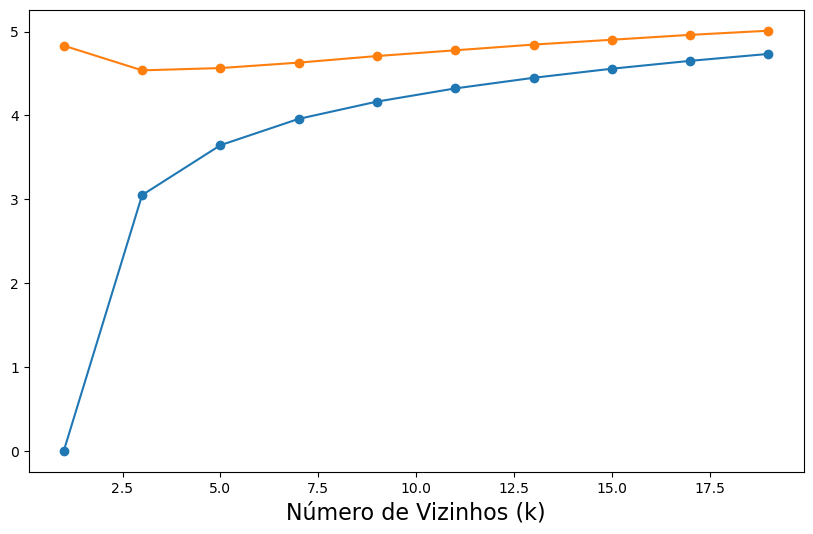

In [10]:
#Otimizando o número de vizinhos

train_score = []
test_score = []

for k in range(1,21,2):
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='minkowski', p=2)
    knn.fit(X_train, y_train)
    train_score.append(mean_absolute_error(y_train, knn.predict(X_train)))
    test_score.append(mean_absolute_error(y_test, knn.predict(X_test)))
    print(f'k={k}, Train MAE={train_score[-1]:.2f}, Test MAE={test_score[-1]:.2f}')


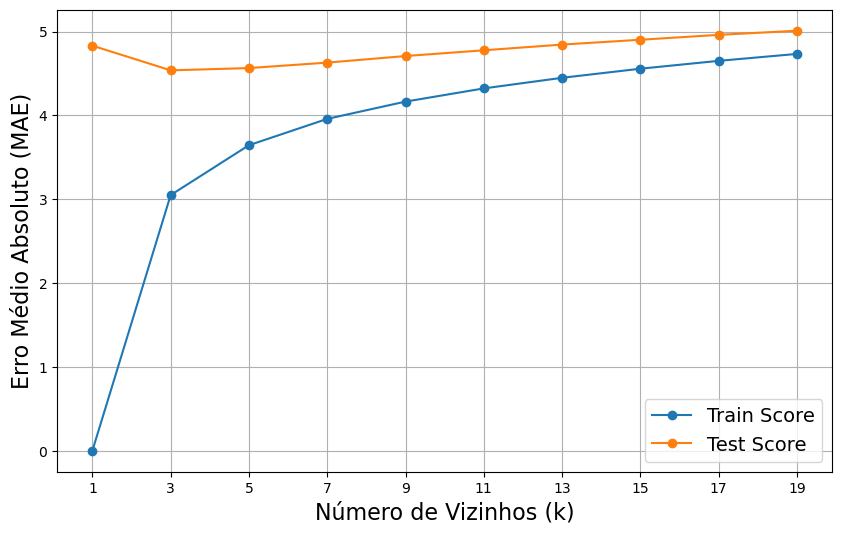

In [15]:
plt.figure(figsize=(10,6))
plt.plot(range(1,21,2), train_score, label='Train Score', marker='o')
plt.plot(range(1,21,2), test_score, label='Test Score', marker='o')
plt.xticks(range(1,21,2))
plt.grid()
plt.xlabel('Número de Vizinhos (k)', fontsize=16)
plt.ylabel('Erro Médio Absoluto (MAE)', fontsize=16)
plt.legend(fontsize=14)

In [33]:
from sklearn.model_selection import PredefinedSplit

#Otimizando o código com o grid search
param_grid = {'n_neighbors': list(range(1,5,2)),
              'weights': ['uniform', 'distance'],
              'metric': ['minkowski'],
                'p': [1,2]}

# Junta os conjuntos (necessário para usar o PredefinedSplit)
X_full = np.concatenate([X_train_scaled, X_test_scaled])
y_full = np.concatenate([y_train, y_test])

# Cria o vetor que define quais amostras pertencem ao treino (-1) e teste (0)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train)),   # treino
     0 * np.ones(len(X_test))     # validação
])

# Cria o split fixo
ps = PredefinedSplit(test_fold)

grid_search = GridSearchCV(KNeighborsRegressor(), 
                           param_grid, 
                           cv=ps, 
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1,
                           return_train_score=True)

grid_search.fit(X_full, y_full)

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'metric': ['minkowski'], 'n_neighbors': [1, 3],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='neg_mean_absolute_error')

In [34]:
print("Melhores hiperparâmetros encontrados:")
print(grid_search.best_params_)

Melhores hiperparâmetros encontrados:
{'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}


In [35]:
df_CV = pd.DataFrame(grid_search.cv_results_)
df_CV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
0,1.231891,0.0,6.662606,0.0,minkowski,1,1,uniform,"{'metric': 'minkowski', 'n_neighbors': 1, 'p':...",-2.387271,-2.387271,0.0,3,-0.000000,0.000000,0.0
1,1.186370,0.0,6.722123,0.0,minkowski,1,1,distance,"{'metric': 'minkowski', 'n_neighbors': 1, 'p':...",-2.387271,-2.387271,0.0,3,-0.000000,0.000000,0.0
2,1.238372,0.0,3.985965,0.0,minkowski,1,2,uniform,"{'metric': 'minkowski', 'n_neighbors': 1, 'p':...",-2.516547,-2.516547,0.0,7,-0.000000,0.000000,0.0
3,1.220366,0.0,4.026973,0.0,minkowski,1,2,distance,"{'metric': 'minkowski', 'n_neighbors': 1, 'p':...",-2.516547,-2.516547,0.0,7,-0.000000,0.000000,0.0
4,1.204367,0.0,10.667793,0.0,minkowski,3,1,uniform,"{'metric': 'minkowski', 'n_neighbors': 3, 'p':...",-2.372138,-2.372138,0.0,2,-1.498329,-1.498329,0.0
5,1.226369,0.0,10.512030,0.0,minkowski,3,1,distance,"{'metric': 'minkowski', 'n_neighbors': 3, 'p':...",-2.268177,-2.268177,0.0,1,-0.000000,0.000000,0.0
6,1.249377,0.0,6.203999,0.0,minkowski,3,2,uniform,"{'metric': 'minkowski', 'n_neighbors': 3, 'p':...",-2.501129,-2.501129,0.0,6,-1.589095,-1.589095,0.0
7,1.201372,0.0,6.259012,0.0,minkowski,3,2,distance,"{'metric': 'minkowski', 'n_neighbors': 3, 'p':...",-2.399401,-2.399401,0.0,5,-0.000000,0.000000,0.0


In [36]:
# Realizando as predições no blind dataset
X_blind_scaled = scaler.transform(blind[columns])
y_blind = blind['DTC']

print('Log do blind')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_blind, grid_search.predict(X_blind_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_blind, grid_search.predict(X_blind_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_blind, grid_search.predict(X_blind_scaled)):.2f}')
print('---'*20)

Log do blind
Erro médio absoluto (MAE): 5.54
Erro quadrático médio (MSE): 62.56
Coeficiente de determinação (R²): 0.82
------------------------------------------------------------


(<Figure size 900x1500 with 5 Axes>,
 array([<Axes: xlabel='GR (uApi)', ylabel='Depth (m)'>,
        <Axes: xlabel='$Res$ ($\\Omega \\cdot m$)'>,
        <Axes: xlabel='$\\Delta t$ ($\\mu$s/ft)'>,
        <Axes: xlabel='g/cm$^3$'>], dtype=object))

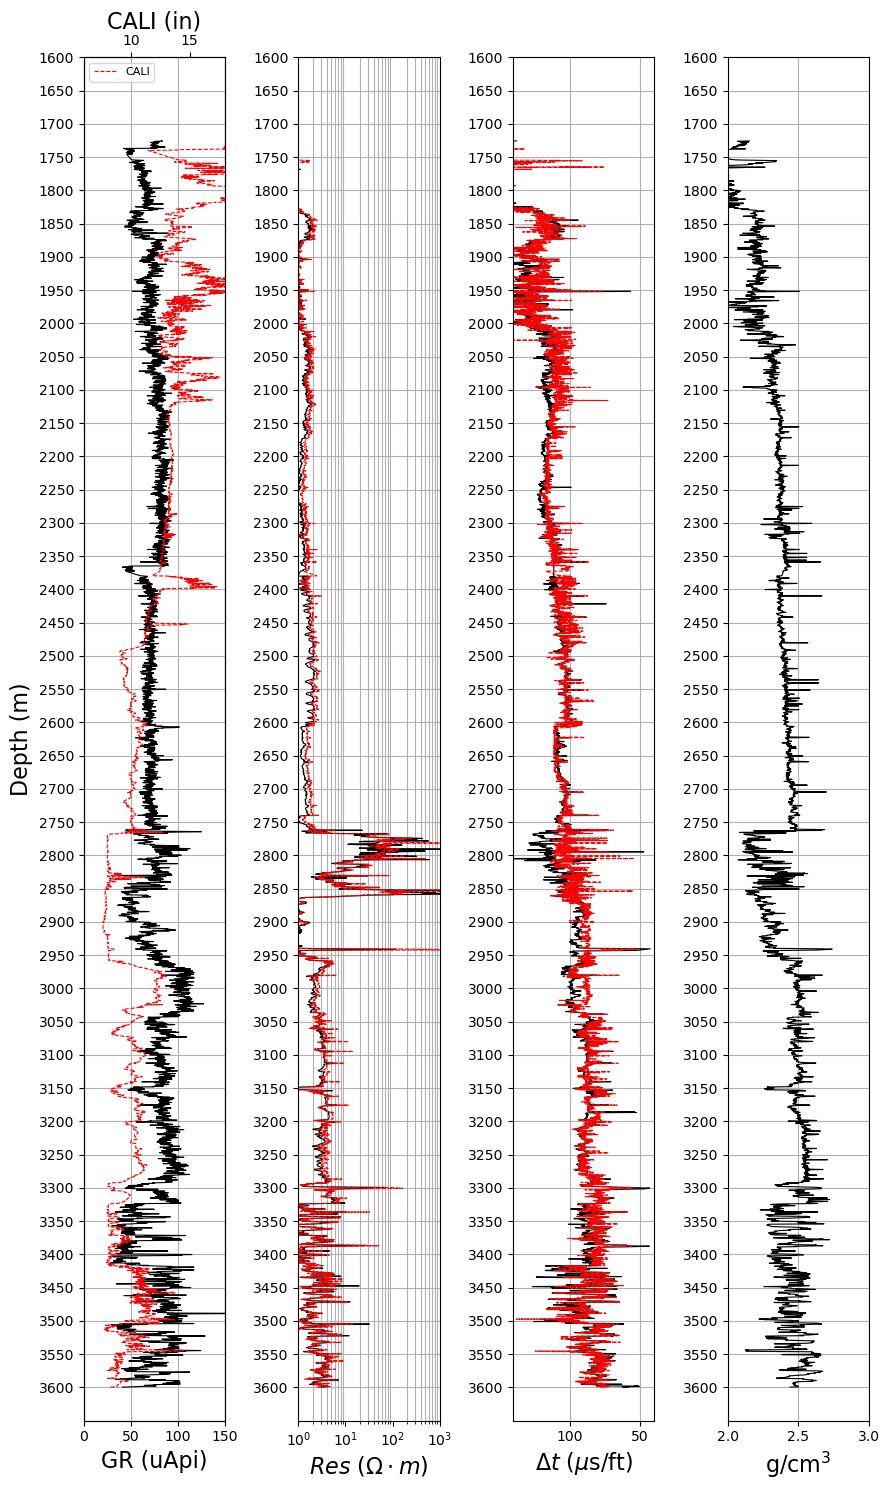

In [43]:
blind['DTC_KNN_Reg'] = grid_search.predict(X_blind_scaled)
plot_dtc_reg_comparison(blind, log_comp='DTC_KNN_Reg')

In [49]:
blind.LITHOLOGY.unique()

array(['Limestone (Calcário)', 'Shale (Argilito)', 'Tuff (Tufo)',
       'Sandstone (Arenito)', 'Dolomite (Dolomita)',
       'Sandstone/Shale (Arenito/Argilito)'], dtype=object)

In [51]:
#Analizando o erro por litologia
for i in blind.LITHOLOGY.unique():
    print(f"Litologia: {i}")
    print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_blind[blind.LITHOLOGY==i], grid_search.predict(X_blind_scaled[blind.LITHOLOGY==i])):.2f}')

Litologia: Limestone (Calcário)
Erro médio absoluto (MAE): 10.67
Litologia: Shale (Argilito)
Erro médio absoluto (MAE): 5.15
Litologia: Tuff (Tufo)
Erro médio absoluto (MAE): 6.27
Litologia: Sandstone (Arenito)
Erro médio absoluto (MAE): 7.24
Litologia: Dolomite (Dolomita)
Erro médio absoluto (MAE): 5.80
Litologia: Sandstone/Shale (Arenito/Argilito)
Erro médio absoluto (MAE): 4.92
